In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler, RobustScaler, OrdinalEncoder

In [65]:
df = pd.read_csv("F:\Jupyter_Projects\Phitron AL ML\Dataset\churn.csv")
display(df.sample(5))

<>:1: SyntaxWarning: invalid escape sequence '\J'
<>:1: SyntaxWarning: invalid escape sequence '\J'
C:\Users\HP\AppData\Local\Temp\ipykernel_20108\2249689278.py:1: SyntaxWarning: invalid escape sequence '\J'
  df = pd.read_csv("F:\Jupyter_Projects\Phitron AL ML\Dataset\churn.csv")


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5997,3462-BJQQA,Female,0,No,No,6,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,89.75,552.65,No
3732,3082-YVEKW,Female,0,Yes,Yes,23,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),77.15,1759.4,No
4228,6416-TVAIH,Male,0,Yes,Yes,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,68.50,68.5,Yes
2708,8510-AWCXC,Female,1,No,No,13,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.80,1308.1,Yes
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [66]:
df.drop('customerID', inplace=True, axis = 1)

In [67]:
df.sample(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6947,Male,0,Yes,Yes,68,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,One year,Yes,Credit card (automatic),101.05,6770.5,No
4094,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,No,Electronic check,74.00,74,No


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [69]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [70]:
df.gender.value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

<Axes: xlabel='gender', ylabel='count'>

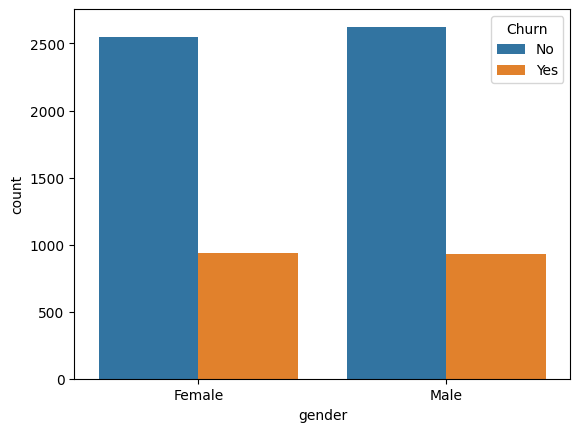

In [71]:
sns.countplot(data = df, x = 'gender', hue = 'Churn')

In [72]:
X = df.drop('Churn', axis = 1)
y = df['Churn'].map({'No': 0, 'Yes': 1})

In [73]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [74]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 19), (1409, 19), (5634,), (1409,))

In [75]:
ohe = OneHotEncoder(sparse_output = False, drop = 'first').set_output(transform = 'pandas')
X_train_gender = ohe.fit_transform(X_train[['gender']])
X_test_gender = ohe.transform(X_test[['gender']])

X_train = pd.concat([X_train.drop(columns = ['gender']), X_train_gender], axis = 1)
X_test = pd.concat([X_test.drop(columns = ['gender']), X_test_gender], axis = 1)
X_train.head(2)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender_Male
2142,0,No,Yes,21,Yes,No,DSL,Yes,No,Yes,No,No,Yes,One year,No,Mailed check,64.85,1336.8,0.0
1623,0,No,No,54,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),97.20,5129.45,0.0


In [76]:
X_train.SeniorCitizen.value_counts()

SeniorCitizen
0    4728
1     906
Name: count, dtype: int64

<Axes: xlabel='SeniorCitizen', ylabel='count'>

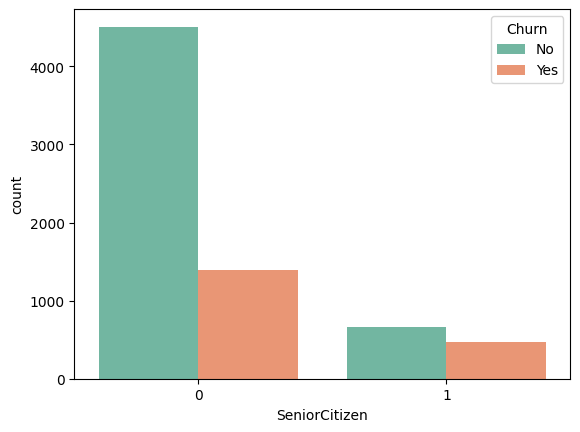

In [77]:
sns.countplot(data = df, x = 'SeniorCitizen', hue = 'Churn', palette = 'Set2')

In [78]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize = 'index') * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [79]:
df['SeniorCitizen'].value_counts() / len(df) * 100

SeniorCitizen
0    83.785319
1    16.214681
Name: count, dtype: float64

In [80]:
X_train.sample(2)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender_Male
246,0,No,No,41,Yes,Yes,DSL,No,No,Yes,No,No,Yes,One year,No,Mailed check,65.0,2531.8,1.0
5329,0,Yes,No,25,No,No phone service,DSL,No,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),34.0,853,0.0


In [81]:
X_train.Partner.value_counts()

Partner
No     2904
Yes    2730
Name: count, dtype: int64

<Axes: xlabel='Partner', ylabel='count'>

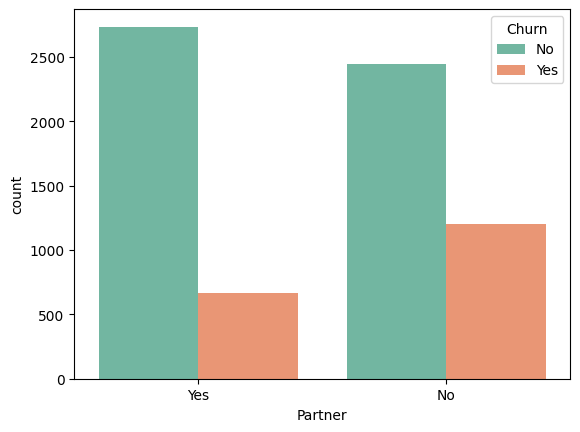

In [82]:
sns.countplot(x = 'Partner', hue = 'Churn', data = df, palette = 'Set2')

In [83]:
pd.crosstab(df.Partner, df.Churn, normalize = 'index') * 100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


In [84]:
X_train.sample(2)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender_Male
4701,1,No,No,21,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,104.35,2271.85,1.0
3127,0,No,No,29,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,30.60,856.35,0.0


In [85]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop = 'first').set_output(transform = 'pandas')

X_train_Partner = ohe.fit_transform(X_train[['Partner']])

X_test_Partner = ohe.transform(X_test[['Partner']])

X_train = pd.concat([X_train.drop(columns = ['Partner']), X_train_Partner], axis = 1)
X_test = pd.concat([X_test.drop(columns = ['Partner']), X_test_Partner], axis = 1)

X_train.sample(2)

,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes
4233,0,No,33,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),59.55,2016.3,0.0,1.0
5899,1,No,67,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,75.70,5060.85,1.0,0.0


In [86]:
display(X_train.Dependents.value_counts())
display(X_train.PhoneService.value_counts())
display(X_train.MultipleLines.value_counts())
display(X_train.InternetService.value_counts())
display(X_train.OnlineSecurity.value_counts())
display(X_train.OnlineBackup.value_counts())
display(X_train.DeviceProtection.value_counts())
display(X_train.TechSupport.value_counts())
display(X_train.StreamingTV.value_counts())
display(X_train.StreamingMovies.value_counts())
display(X_train.PaperlessBilling.value_counts())

Dependents
No     3951
Yes    1683
Name: count, dtype: int64

PhoneService
Yes    5082
No      552
Name: count, dtype: int64

MultipleLines
No                  2685
Yes                 2397
No phone service     552
Name: count, dtype: int64

InternetService
Fiber optic    2481
DSL            1939
No             1214
Name: count, dtype: int64

OnlineSecurity
No                     2810
Yes                    1610
No internet service    1214
Name: count, dtype: int64

...

DeviceProtection
No                     2489
Yes                    1931
No internet service    1214
Name: count, dtype: int64

TechSupport
No                     2791
Yes                    1629
No internet service    1214
Name: count, dtype: int64

StreamingTV
No                     2239
Yes                    2181
No internet service    1214
Name: count, dtype: int64

StreamingMovies
No                     2223
Yes                    2197
No internet service    1214
Name: count, dtype: int64

PaperlessBilling
Yes    3325
No     2309
Name: count, dtype: int64

In [87]:
columns = ['Dependents','PaymentMethod','PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

ohe = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore', drop = 'first').set_output(transform = 'pandas')
X_train_encoded = ohe.fit_transform(X_train[columns])
X_test_encoded = ohe.transform(X_test[columns])

X_train = pd.concat([X_train.drop(columns = columns), X_train_encoded], axis = 1)
X_test = pd.concat([X_test.drop(columns = columns), X_test_encoded], axis = 1)
X_train.sample(2)

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes
871,0,57,One year,97.55,5598,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
6840,0,1,Month-to-month,19.30,19.3,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0


In [88]:
X_train.Contract.value_counts()

Contract
Month-to-month    3083
Two year          1339
One year          1212
Name: count, dtype: int64

In [89]:
X_train['Contract'] = X_train.Contract.map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

X_test['Contract'] = X_test.Contract.map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

In [90]:
X_train.sample(2)

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes
3133,0,70,1,51.05,3635.15,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3442,0,29,0,98.80,2807.1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0


In [92]:
X_train.sample(2)

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes
781,0,5,0,44.80,220.45,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5372,1,50,0,104.95,5222.35,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0


<Axes: xlabel='MonthlyCharges', ylabel='Density'>

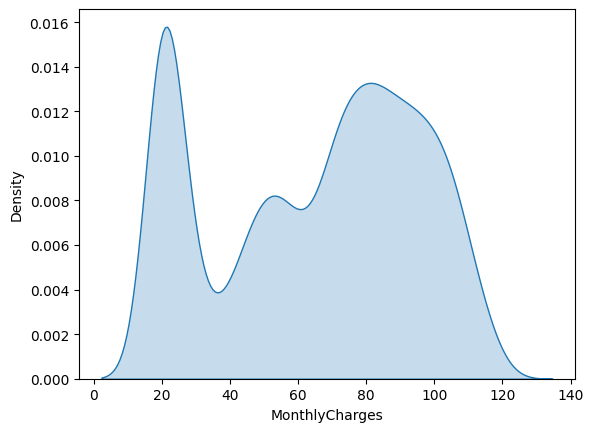

In [93]:
sns.kdeplot(data = X_train, x = 'MonthlyCharges', fill = True)

In [97]:
scaler = StandardScaler()
X_train['MonthlyCharges'] = scaler.fit_transform(X_train[['MonthlyCharges']])
X_test['MonthlyCharges'] = scaler.transform(X_test[['MonthlyCharges']])

In [96]:
X_train.TotalCharges.dtype

dtype('O')

In [98]:
X_train['TotalCharges'] = pd.to_numeric(X_train['TotalCharges'], errors = 'coerce')
X_test['TotalCharges'] = pd.to_numeric(X_test['TotalCharges'], errors = 'coerce')

X_train['TotalCharges'] = X_train['TotalCharges'].fillna(X_train['TotalCharges'].median())
X_test['TotalCharges'] = X_test['TotalCharges'].fillna(X_train['TotalCharges'].median())

<Axes: xlabel='TotalCharges', ylabel='Density'>

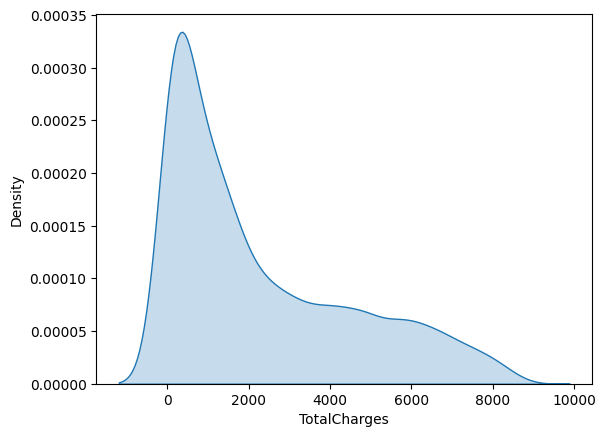

In [99]:
sns.kdeplot(data = X_train, x = 'TotalCharges', fill = True)

In [100]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method = 'yeo-johnson')

X_train['TotalCharges'] = pt.fit_transform(X_train[['TotalCharges']])
X_test['TotalCharges'] = pt.transform(X_test[['TotalCharges']])

<Axes: xlabel='TotalCharges', ylabel='Density'>

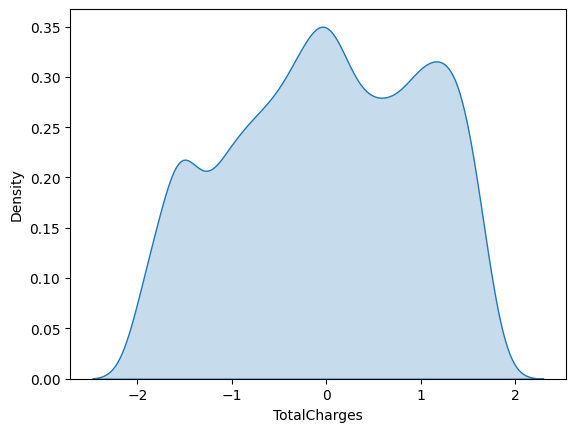

In [101]:
sns.kdeplot(data = X_train, x = 'TotalCharges', fill = True)

In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [103]:
models = {
    'Logistic Regression': LogisticRegression(max_iter = 1000),
    'Random Forest': RandomForestClassifier(random_state = 42),
    'XGBoost': XGBClassifier(random_state = 42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Model: {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 50)

Model: Logistic Regression
Accuracy: 0.8112136266855926
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.67      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
[[936 100]
 [166 207]]
--------------------------------------------------
Model: Random Forest
Accuracy: 0.7906316536550745
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.65      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix:
[[943  93]
 [202 171]]
--------------------------------------------------
Model: XGB